<a href="https://colab.research.google.com/github/aHandoumeh/House-Price-Prediction/blob/main/4_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "housing.csv"

data = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "camnugent/california-housing-prices",
  file_path,
)


/tmp/ipykernel_17545/291493479.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  data = kagglehub.load_dataset(


Using Colab cache for faster access to the 'california-housing-prices' dataset.


In [3]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
data.shape

(20640, 10)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
data.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [7]:
data=data.dropna()

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [10]:
cat_cols = data.select_dtypes(include=['object']).columns
num_cols = data.select_dtypes(exclude=['object']).columns

<Axes: xlabel='ocean_proximity', ylabel='count'>

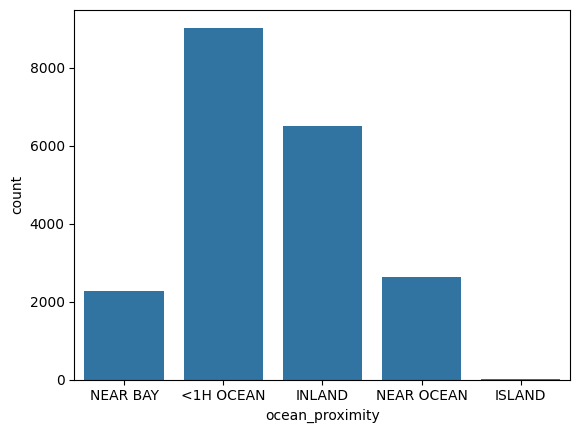

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=data, x=cat_cols[0])

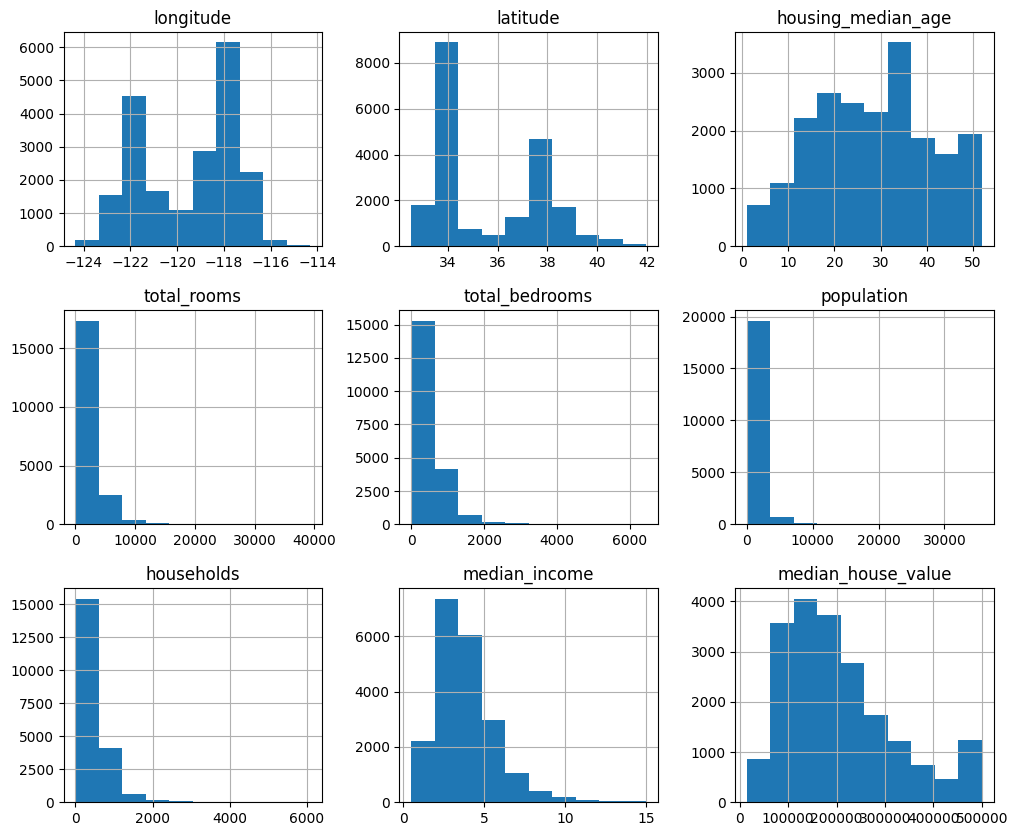

In [12]:
data.hist(figsize=(12, 10))
plt.show()

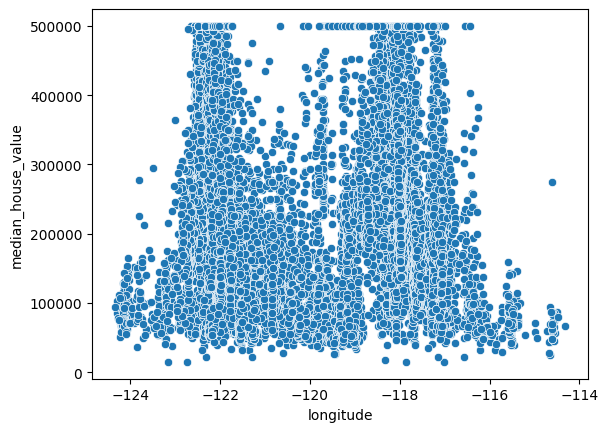

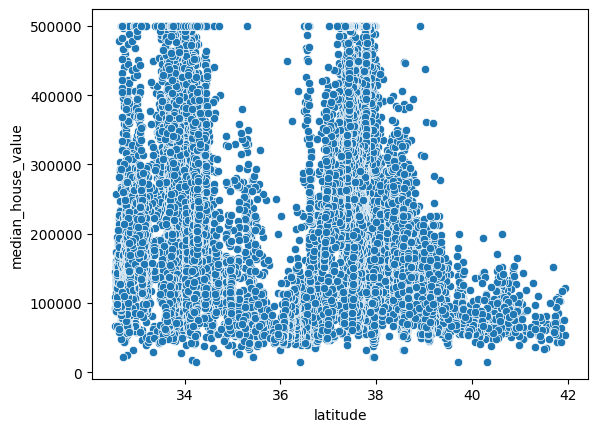

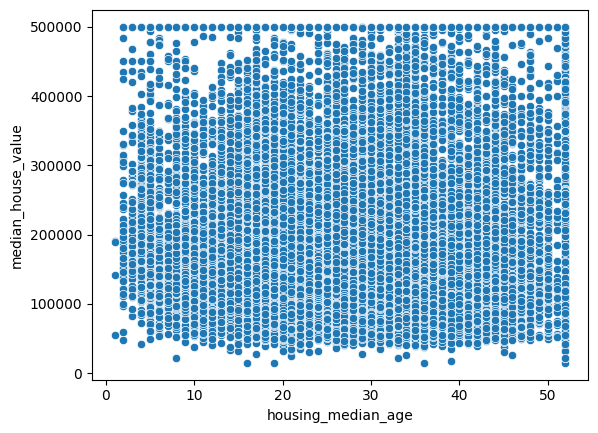

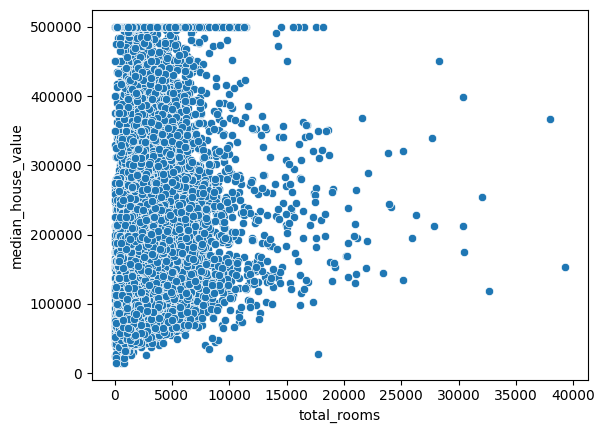

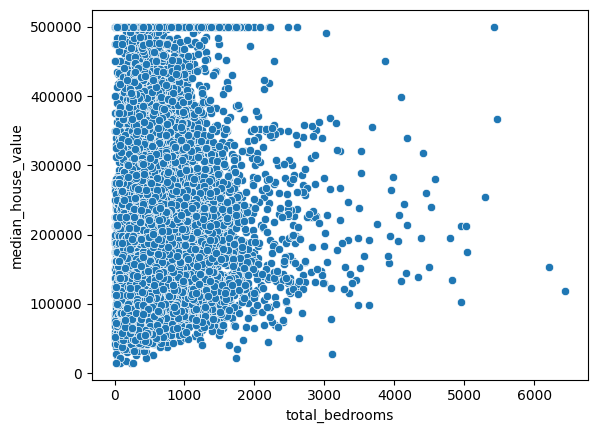

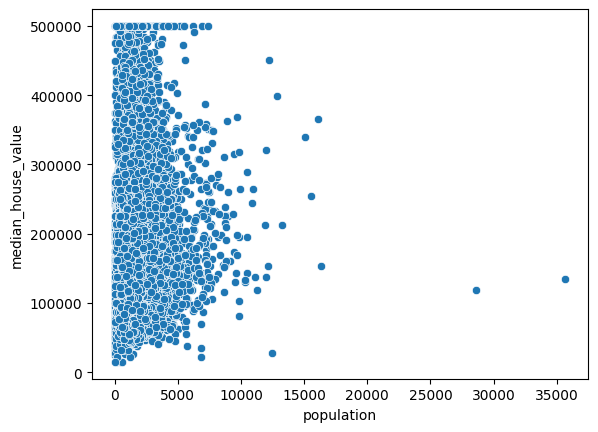

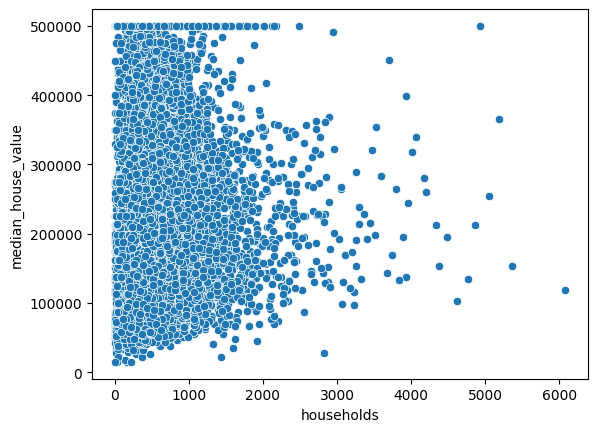

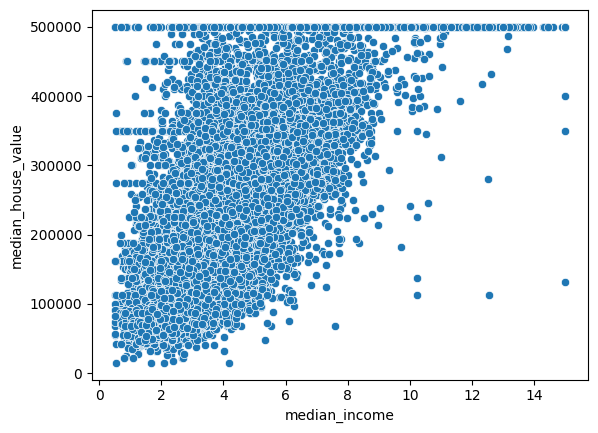

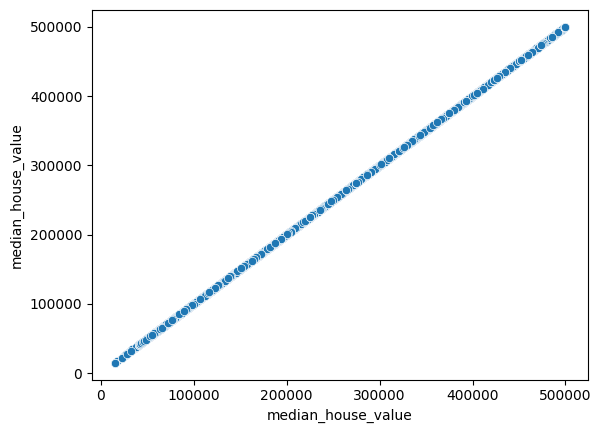

In [13]:
for col in num_cols:
  sns.scatterplot(x=col, y='median_house_value', data=data)
  plt.show()

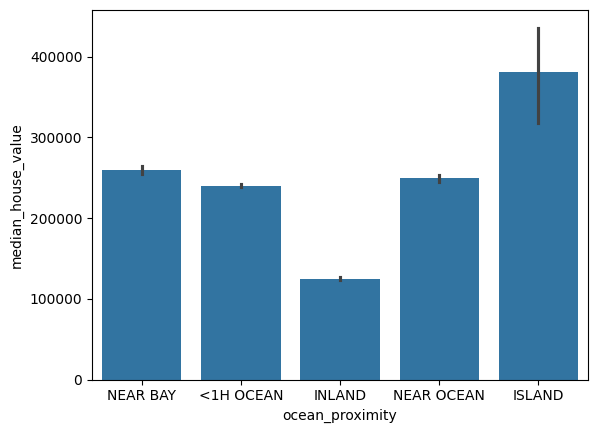

In [14]:
sns.barplot(x=cat_cols[0], y='median_house_value', data=data)
plt.show()

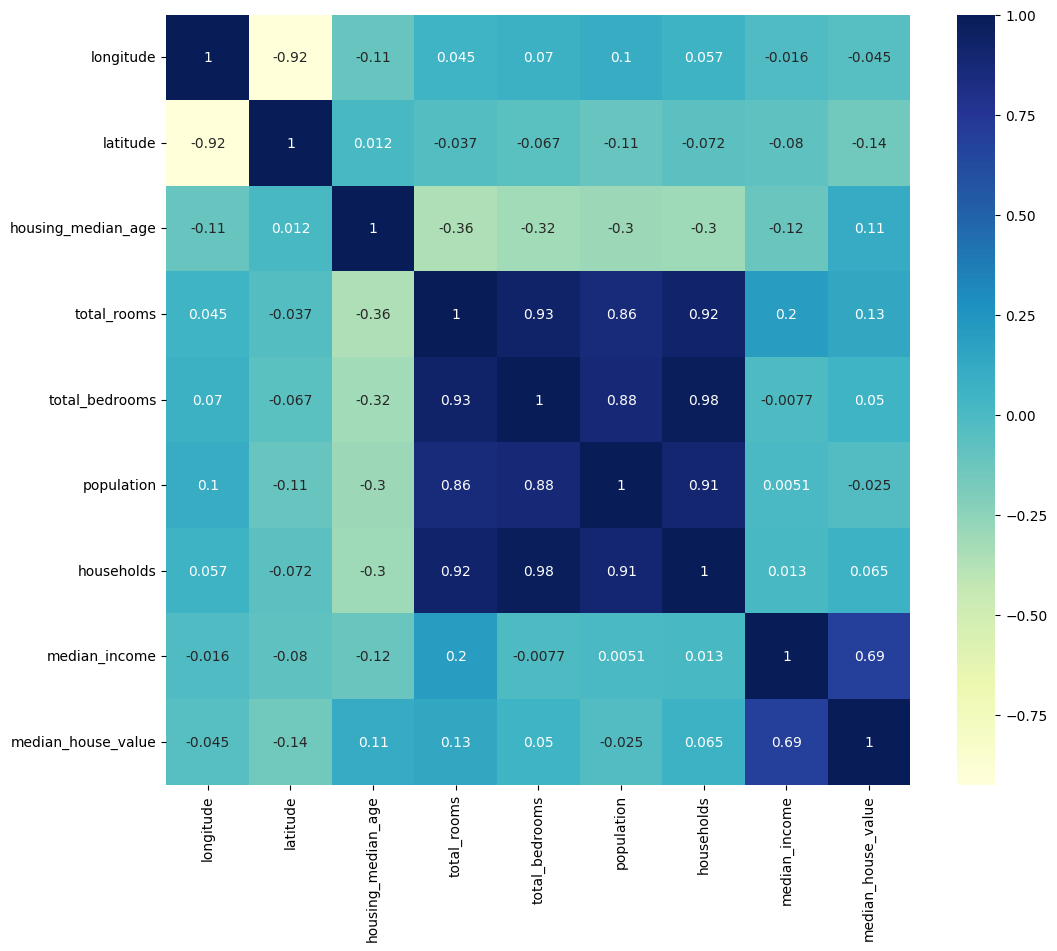

In [15]:
co=data[num_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(co, annot=True, cmap='YlGnBu')
plt.show()

In [16]:
data = data.join(pd.get_dummies(data[cat_cols[0]], dtype=int)).drop('ocean_proximity', axis=1)

In [17]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0


In [18]:
data['ISLAND'].value_counts()

,count
ISLAND,
0,20428
1,5


In [19]:
data=data.drop('ISLAND', axis=1)

In [20]:
import numpy as np
data['total_rooms']=np.log(data['total_rooms']+1)
data['total_bedrooms']=np.log(data['total_bedrooms']+1)
data['population']=np.log(data['population']+1)
data['households']=np.log(data['households']+1)

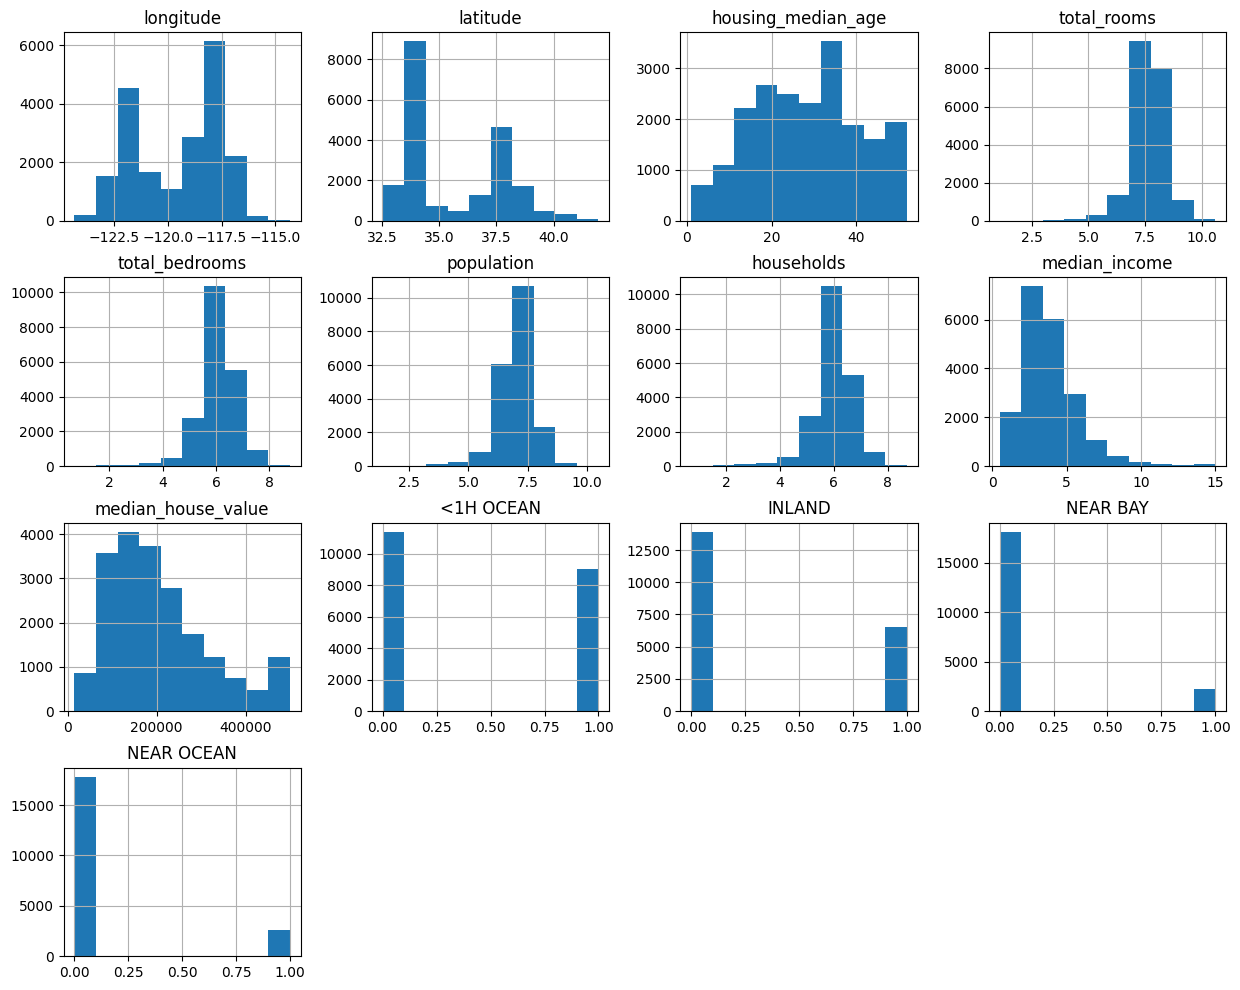

In [21]:
data.hist(figsize=(15, 12))
plt.show()

<Axes: xlabel='latitude', ylabel='longitude'>

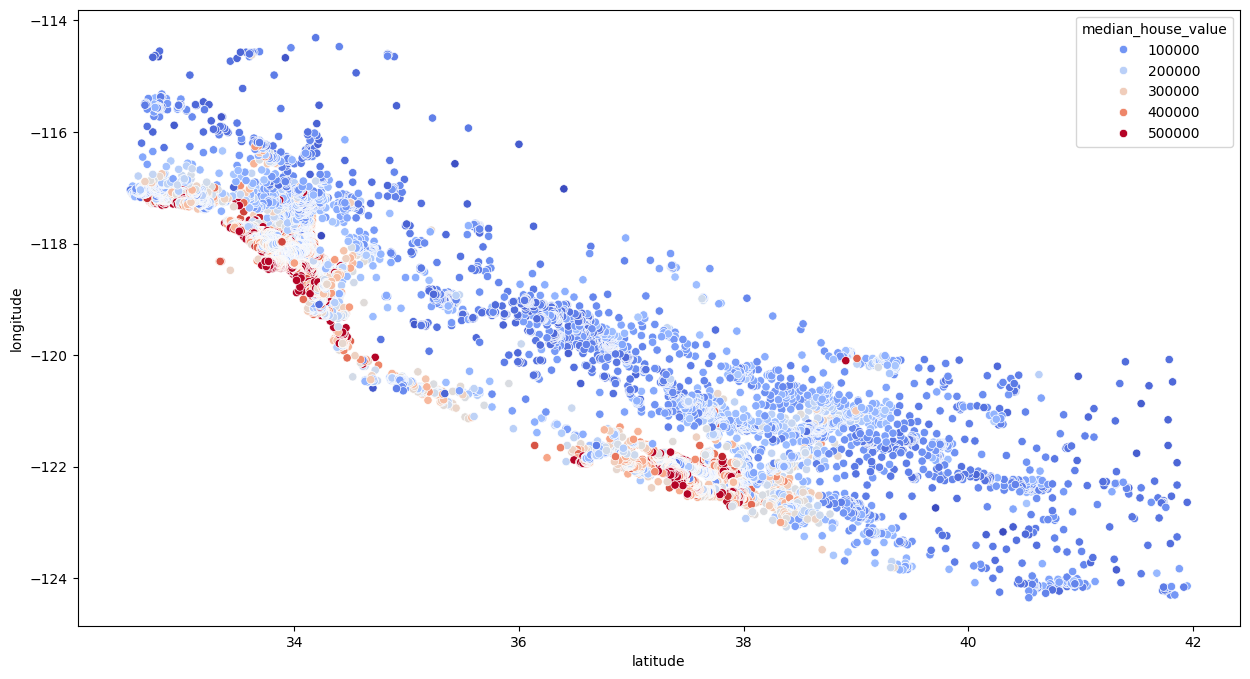

In [22]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x='latitude', y='longitude', data=data, hue='median_house_value', palette='coolwarm')

In [23]:
data['bedroom_rate']=data['total_bedrooms'] / data['total_rooms']
data['household_rooms']=data['total_rooms'] / data['households']

<Axes: >

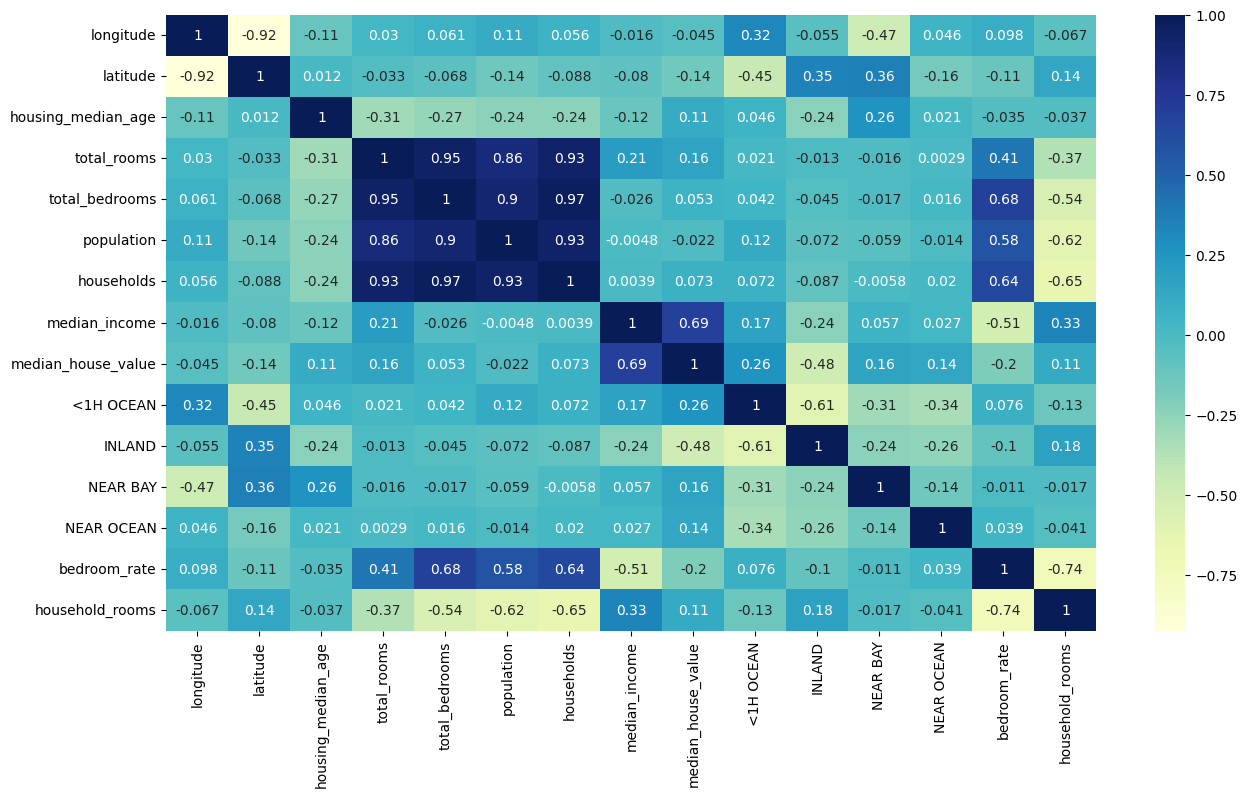

In [24]:
plt.figure(figsize=(15, 8))
sns.heatmap(data.corr(), annot=True, cmap='YlGnBu')
# the new features have better corr

In [25]:
X, y=data.drop('median_house_value', axis=1), data['median_house_value']

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16346, 14), (4087, 14), (16346,), (4087,))

In [27]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)

In [28]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [29]:
X_test_scaled=scaler.transform(X_test)
model.score(X_test_scaled, y_test)

0.6685694934056108

In [30]:
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor()
model.fit(X_train, y_train)


RandomForestRegressor()

In [31]:
model.score(X_test, y_test)

0.8207546799123531

In [32]:
# with scaling:
model.fit(X_train_scaled, y_train)
model.score(X_test_scaled, y_test)

0.8234279539756042

In [33]:
from sklearn.model_selection import GridSearchCV

forest=RandomForestRegressor()

param_grid={
      'n_estimators':[3, 10, 30],
      'max_features':[2, 4, 6, 8],


}

grid_search=GridSearchCV(forest, param_grid, cv=5,
                        scoring='neg_mean_squared_error',
                        return_train_score=True)
grid_search.fit(X_train_scaled, y_train)





GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_features': [2, 4, 6, 8],
                         'n_estimators': [3, 10, 30]},
             return_train_score=True, scoring='neg_mean_squared_error')

In [34]:
best_one = grid_search.best_estimator_

In [35]:
best_one.score(X_test_scaled, y_test)
# it's not necessary that result better score

0.8177691499241165

In [36]:
predictions = model.predict(X_test_scaled)
predictions

array([120862., 198065., 156407., ..., 257027., 212936., 195512.])

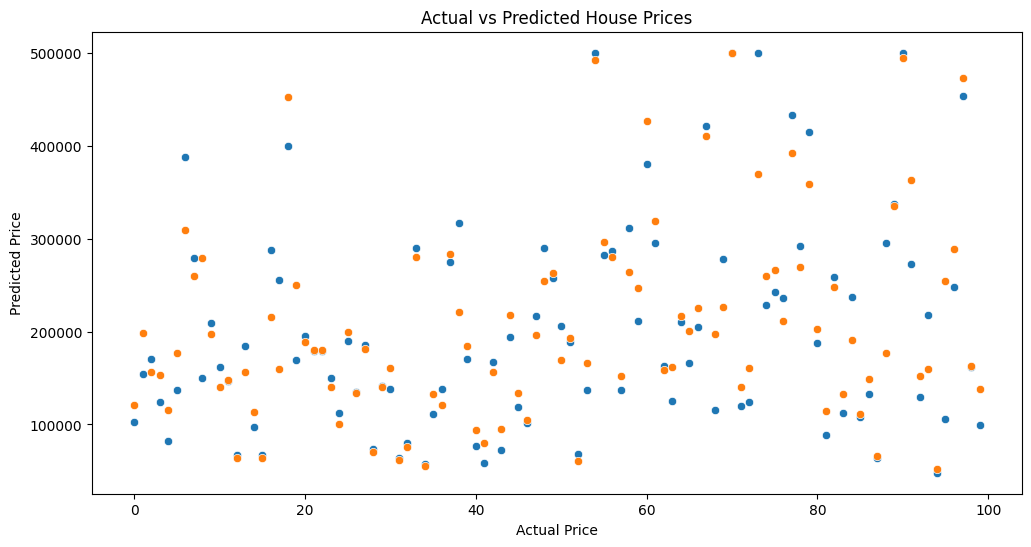

In [37]:
plt.figure(figsize=(12, 6))
sns.scatterplot(y_test.reset_index(drop=True)[:100])
sns.scatterplot(predictions[:100])
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()


In [38]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
root_mean_squared_error(predictions, y_test)

47578.52364097013

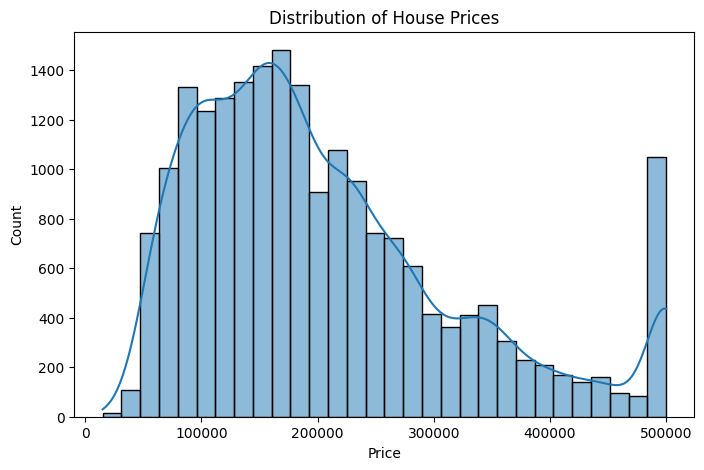

In [39]:
plt.figure(figsize=(8, 5))
sns.histplot(data['median_house_value'], bins=30, kde=True)

plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()